In [ ]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
import os, numpy as np, pandas as pd, ast, torch

BASE = "/content/drive/MyDrive/Colab Notebooks"
X_NPY = os.path.join(BASE, "X_ptbxl_500hz.npy")
META  = os.path.join(BASE, "ptbxl_database.csv")
SCP   = os.path.join(BASE, "scp_statements.csv")

print("X:", os.path.exists(X_NPY))
print("META:", os.path.exists(META))
print("SCP:", os.path.exists(SCP))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

X: True
META: True
SCP: True
Device: cuda


In [ ]:
!cp "{X_NPY}" /content/X_ptbxl_500hz.npy

X = np.load("/content/X_ptbxl_500hz.npy", mmap_mode="r")
print("X shape:", X.shape)  # expect (21799, 12, 5000) or (21799, 5000, 12)


X shape: (21799, 12, 5000)


In [ ]:
meta = pd.read_csv(META)
meta["scp_codes"] = meta["scp_codes"].apply(ast.literal_eval)

classes = ["NORM", "IMI", "ASMI", "LVH", "NDT", "LAFB"]
class_to_idx = {c:i for i,c in enumerate(classes)}

N = len(meta)
C = len(classes)
y = np.zeros((N, C), dtype=np.float32)

for i, codes in enumerate(meta["scp_codes"]):
    for code in codes.keys():
        if code in class_to_idx:
            y[i, class_to_idx[code]] = 1.0

print("y shape:", y.shape)
print("Positive rate:", dict(zip(classes, y.mean(axis=0))))
assert X.shape[0] == y.shape[0] == len(meta)


y shape: (21799, 6)
Positive rate: {'NORM': np.float32(0.43644205), 'IMI': np.float32(0.12275793), 'ASMI': np.float32(0.10812423), 'LVH': np.float32(0.097802654), 'NDT': np.float32(0.08371944), 'LAFB': np.float32(0.07445296)}


In [ ]:
from sklearn.model_selection import GroupShuffleSplit
import numpy as np

groups = meta["patient_id"].values
idx_all = np.arange(N)

gss = GroupShuffleSplit(test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss.split(idx_all, y, groups))

gss2 = GroupShuffleSplit(test_size=0.25, random_state=42)
train_rel, val_rel = next(gss2.split(train_val_idx, y[train_val_idx], groups[train_val_idx]))

train_idx = train_val_idx[train_rel]
val_idx   = train_val_idx[val_rel]

print("train/val/test:", len(train_idx), len(val_idx), len(test_idx))

train_p = set(groups[train_idx]); val_p = set(groups[val_idx]); test_p = set(groups[test_idx])
print("Overlap train-val:", len(train_p & val_p))
print("Overlap train-test:", len(train_p & test_p))
print("Overlap val-test:", len(val_p & test_p))


train/val/test: 13121 4302 4376
Overlap train-val: 0
Overlap train-test: 0
Overlap val-test: 0


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class PTBXLDataset(Dataset):
    def __init__(self, X_memmap, y_array, indices, normalize=True):
        self.X = X_memmap
        self.y = y_array
        self.indices = np.asarray(indices)
        self.normalize = normalize

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        x = self.X[idx].astype(np.float32)

        # ensure (12,5000)
        if x.shape == (5000, 12):
            x = x.T

        # per-lead z-score
        if self.normalize:
            mean = x.mean(axis=1, keepdims=True)
            std  = x.std(axis=1, keepdims=True) + 1e-6
            x = (x - mean) / std

        y = self.y[idx].astype(np.float32)
        return torch.from_numpy(x), torch.from_numpy(y)

batch_size = 32
train_ds = PTBXLDataset(X, y, train_idx)
val_ds   = PTBXLDataset(X, y, val_idx)
test_ds  = PTBXLDataset(X, y, test_idx)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

xb, yb = next(iter(train_loader))
print("batch x:", xb.shape, "batch y:", yb.shape)


batch x: torch.Size([32, 12, 5000]) batch y: torch.Size([32, 6])


In [ ]:
import torch.nn as nn

class ECG_CNN_BiLSTM(nn.Module):
    def __init__(self, n_classes, lstm_hidden=128, lstm_layers=1, dropout=0.2):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(12, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),   # 5000 -> 2500

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),   # 2500 -> 1250

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
        )

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(2 * lstm_hidden, n_classes)

    def forward(self, x):
        x = self.cnn(x)          # (B,128,T')
        x = x.transpose(1, 2)    # (B,T',128)
        out, _ = self.lstm(x)    # (B,T',2H)
        last = out[:, -1, :]     # (B,2H)
        last = self.dropout(last)
        return self.head(last)

model = ECG_CNN_BiLSTM(n_classes=y.shape[1], lstm_hidden=128, lstm_layers=1, dropout=0.2).to(device)
print(model)


ECG_CNN_BiLSTM(
  (cnn): Sequential(
    (0): Conv1d(12, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(5,), stride=(1,), padding=(2,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (head): Linear(in_features=256, out_features=6, bias=True)
)


In [ ]:
import time
import numpy as np
from sklearn.metrics import roc_auc_score

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def sigmoid_np(x):
    return 1 / (1 + np.exp(-x))

def macro_auroc(y_true, probs):
    aucs = []
    for c in range(y_true.shape[1]):
        if len(np.unique(y_true[:, c])) < 2:
            aucs.append(np.nan)
        else:
            aucs.append(roc_auc_score(y_true[:, c], probs[:, c]))
    return float(np.nanmean(aucs)), aucs

def run_epoch(loader, train=False):
    model.train() if train else model.eval()
    total_loss = 0.0
    all_logits, all_y = [], []

    for xb, yb in loader:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        if train:
            optimizer.zero_grad()

        logits = model(xb)
        loss = criterion(logits, yb)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        all_logits.append(logits.detach().cpu().numpy())
        all_y.append(yb.detach().cpu().numpy())

    all_logits = np.concatenate(all_logits, axis=0)
    all_y = np.concatenate(all_y, axis=0)
    return total_loss / len(loader.dataset), all_logits, all_y


# ----------------------------
# Training loop with timing
# ----------------------------
best_val_loss = float("inf")
best_path = "/content/best_ecg_cnn_bilstm_6labels.pt"
epochs = 30

start_time = time.time()
epochs_trained = 0

for epoch in range(1, epochs + 1):
    epoch_start = time.time()
    epochs_trained = epoch

    tr_loss, _, _ = run_epoch(train_loader, train=True)
    va_loss, va_logits, va_y = run_epoch(val_loader, train=False)

    va_probs = sigmoid_np(va_logits)
    va_macro_auc, _ = macro_auroc(va_y, va_probs)

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        torch.save(model.state_dict(), best_path)
        status = "saved"
    else:
        status = "—"

    epoch_time = time.time() - epoch_start

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {tr_loss:.4f} | "
        f"val loss {va_loss:.4f} | "
        f"val macro-AUROC {va_macro_auc:.4f} | "
        f"time {epoch_time:.1f}s | "
        f"{status}"
    )

end_time = time.time()
total_time = end_time - start_time

hours = int(total_time // 3600)
minutes = int((total_time % 3600) // 60)
seconds = int(total_time % 60)

print("\n===== TRAINING SUMMARY =====")
print(f"Total epochs trained : {epochs_trained}")
print(f"Total training time  : {hours}h {minutes}m {seconds}s")
print("Best model saved:", best_path)
print("Best val loss:", best_val_loss)


Epoch 01 | train loss 0.3648 | val loss 0.3531 | val macro-AUROC 0.7110 | time 10.8s | saved
Epoch 02 | train loss 0.3346 | val loss 0.3162 | val macro-AUROC 0.7454 | time 9.5s | saved
Epoch 03 | train loss 0.3327 | val loss 0.3289 | val macro-AUROC 0.7208 | time 9.3s | —
Epoch 04 | train loss 0.3245 | val loss 0.3165 | val macro-AUROC 0.7511 | time 9.4s | —
Epoch 05 | train loss 0.3226 | val loss 0.3089 | val macro-AUROC 0.7748 | time 9.5s | saved
Epoch 06 | train loss 0.3112 | val loss 0.2969 | val macro-AUROC 0.7930 | time 9.3s | saved
Epoch 07 | train loss 0.3038 | val loss 0.2846 | val macro-AUROC 0.8131 | time 9.3s | saved
Epoch 08 | train loss 0.2855 | val loss 0.2731 | val macro-AUROC 0.8311 | time 9.4s | saved
Epoch 09 | train loss 0.2694 | val loss 0.2879 | val macro-AUROC 0.8420 | time 9.2s | —
Epoch 10 | train loss 0.2643 | val loss 0.2640 | val macro-AUROC 0.8455 | time 9.2s | saved
Epoch 11 | train loss 0.2593 | val loss 0.2532 | val macro-AUROC 0.8642 | time 9.2s | saved

In [ ]:
# #
# # =========================
# # CNN + BiLSTM TRAINING CELL (with Early Stopping)
# # Paste this whole cell (it includes everything you need in this section)
# # Assumes you already defined: model, device, train_loader, val_loader, classes
# # =========================

# import numpy as np
# import torch
# import torch.nn as nn
# from sklearn.metrics import roc_auc_score

# # ---- loss/optimizer ----
# criterion = nn.BCEWithLogitsLoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# # ---- helpers ----
# def sigmoid_np(x):
#     return 1 / (1 + np.exp(-x))

# def macro_auroc(y_true, probs):
#     aucs = []
#     for c in range(y_true.shape[1]):
#         if len(np.unique(y_true[:, c])) < 2:
#             aucs.append(np.nan)
#         else:
#             aucs.append(roc_auc_score(y_true[:, c], probs[:, c]))
#     return float(np.nanmean(aucs)), aucs

# def run_epoch(loader, train=False):
#     model.train() if train else model.eval()
#     total_loss = 0.0
#     all_logits, all_y = [], []

#     for xb, yb in loader:
#         xb = xb.to(device, non_blocking=True)
#         yb = yb.to(device, non_blocking=True)

#         if train:
#             optimizer.zero_grad()

#         logits = model(xb)
#         loss = criterion(logits, yb)

#         if train:
#             loss.backward()
#             optimizer.step()

#         total_loss += loss.item() * xb.size(0)
#         all_logits.append(logits.detach().cpu().numpy())
#         all_y.append(yb.detach().cpu().numpy())

#     all_logits = np.concatenate(all_logits, axis=0)
#     all_y = np.concatenate(all_y, axis=0)
#     return total_loss / len(loader.dataset), all_logits, all_y

# # ---- Early stopping training loop ----
# best_val_loss = float("inf")
# best_path = "/content/best_ecg_cnn_bilstm_6labels.pt"

# epochs = 30        # train up to 30
# patience = 5       # stop if val loss doesn't improve for 5 epochs
# wait = 0

# for epoch in range(1, epochs + 1):
#     tr_loss, _, _ = run_epoch(train_loader, train=True)
#     va_loss, va_logits, va_y = run_epoch(val_loader, train=False)

#     va_probs = sigmoid_np(va_logits)
#     va_macro_auc, _ = macro_auroc(va_y, va_probs)

#     if va_loss < best_val_loss:
#         best_val_loss = va_loss
#         wait = 0
#         torch.save(model.state_dict(), best_path)
#         status = "✅ saved"
#     else:
#         wait += 1
#         status = f"wait {wait}/{patience}"

#     print(
#         f"Epoch {epoch:02d} | "
#         f"train loss {tr_loss:.4f} | "
#         f"val loss {va_loss:.4f} | "
#         f"val macro-AUROC {va_macro_auc:.4f} | "
#         f"{status}"
#     )

#     if wait >= patience:
#         print("🛑 Early stopping triggered.")
#         break

# print("✅ Best model saved:", best_path, "| best val loss:", best_val_loss)


Epoch 01 | train loss 0.2435 | val loss 0.2402 | val macro-AUROC 0.8811 | ✅ saved
Epoch 02 | train loss 0.2396 | val loss 0.2430 | val macro-AUROC 0.8799 | wait 1/5
Epoch 03 | train loss 0.2352 | val loss 0.2381 | val macro-AUROC 0.8870 | ✅ saved
Epoch 04 | train loss 0.2270 | val loss 0.2281 | val macro-AUROC 0.8924 | ✅ saved
Epoch 05 | train loss 0.2215 | val loss 0.2219 | val macro-AUROC 0.8987 | ✅ saved
Epoch 06 | train loss 0.2160 | val loss 0.2234 | val macro-AUROC 0.8986 | wait 1/5
Epoch 07 | train loss 0.2109 | val loss 0.2184 | val macro-AUROC 0.9038 | ✅ saved
Epoch 08 | train loss 0.2054 | val loss 0.2124 | val macro-AUROC 0.9068 | ✅ saved
Epoch 09 | train loss 0.2026 | val loss 0.2240 | val macro-AUROC 0.9051 | wait 1/5
Epoch 10 | train loss 0.2010 | val loss 0.2170 | val macro-AUROC 0.9070 | wait 2/5
Epoch 11 | train loss 0.1923 | val loss 0.2118 | val macro-AUROC 0.9105 | ✅ saved
Epoch 12 | train loss 0.1911 | val loss 0.2149 | val macro-AUROC 0.9105 | wait 1/5
Epoch 13 | 

In [ ]:
model.load_state_dict(torch.load(best_path, map_location=device))

te_loss, te_logits, te_y = run_epoch(test_loader, train=False)
te_probs = sigmoid_np(te_logits)

te_macro_auc, te_aucs = macro_auroc(te_y, te_probs)

print("\nTEST loss:", te_loss)
print("TEST macro-AUROC:", te_macro_auc)
print("Per-class AUROC:")
for cls, aucv in zip(classes, te_aucs):
    print(f"  {cls:6s}: {aucv}")



TEST loss: 0.20003285105093305
TEST macro-AUROC: 0.9246856150047793
Per-class AUROC:
  NORM  : 0.9376395180152175
  IMI   : 0.9340798245730796
  ASMI  : 0.9545407866360868
  LVH   : 0.8749949254240316
  NDT   : 0.8668510747392425
  LAFB  : 0.9800075606410176


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

threshold = 0.5
y_true = te_y.astype(int)
y_pred = (te_probs >= threshold).astype(int)

# Subset accuracy (strict)
subset_acc = accuracy_score(y_true, y_pred)

# "Normal" accuracy (element-wise)
label_accuracy = (y_true == y_pred).mean()

macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall    = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1        = f1_score(y_true, y_pred, average="macro", zero_division=0)

print("=== TEST METRICS (threshold=0.5) ===")
print(f"Subset Accuracy (exact match) : {subset_acc:.4f}")
print(f"Label Accuracy (element-wise): {label_accuracy:.4f}")
print(f"Macro Precision              : {macro_precision:.4f}")
print(f"Macro Recall                 : {macro_recall:.4f}")
print(f"Macro F1-score               : {macro_f1:.4f}")

print("\n=== Per-class Accuracy, Precision, Recall, and F1-Score ===")
for i, cls in enumerate(classes):
    accuracy  = (y_true[:, i] == y_pred[:, i]).mean()   # ✅ per-label normal accuracy
    precision = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
    recall    = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)
    f1        = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)
    support   = int(y_true[:, i].sum())

    print(
        f"{cls:6s} | "
        f"Accuracy: {accuracy:.4f} | "
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1-score: {f1:.4f} | "
        f"Positive samples: {support}"
    )


=== TEST METRICS (threshold=0.5) ===
Subset Accuracy (exact match) : 0.6312
Label Accuracy (element-wise): 0.9179
Macro Precision              : 0.6901
Macro Recall                 : 0.5256
Macro F1-score               : 0.5608

=== Per-class Accuracy, Precision, Recall, and F1-Score ===
NORM   | Accuracy: 0.8622 | Precision: 0.8073 | Recall: 0.9065 | F1-score: 0.8540 | Positive samples: 1946
IMI    | Accuracy: 0.9116 | Precision: 0.7318 | Recall: 0.4194 | F1-score: 0.5332 | Positive samples: 527
ASMI   | Accuracy: 0.9433 | Precision: 0.8300 | Recall: 0.5583 | F1-score: 0.6676 | Positive samples: 446
LVH    | Accuracy: 0.9205 | Precision: 0.6267 | Recall: 0.3375 | F1-score: 0.4387 | Positive samples: 403
NDT    | Accuracy: 0.9157 | Precision: 0.5082 | Recall: 0.0838 | F1-score: 0.1439 | Positive samples: 370
LAFB   | Accuracy: 0.9541 | Precision: 0.6366 | Recall: 0.8481 | F1-score: 0.7273 | Positive samples: 316


In [ ]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

supports = np.array([y_true[:, i].sum() for i in range(len(classes))])
weights = supports / supports.sum()

prec_list, rec_list, f1_list = [], [], []

for i in range(len(classes)):
    prec = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
    rec  = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)
    f1   = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)

    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)

prec_list = np.array(prec_list)
rec_list  = np.array(rec_list)
f1_list   = np.array(f1_list)

weighted_precision = np.sum(weights * prec_list)
weighted_recall    = np.sum(weights * rec_list)
weighted_f1        = np.sum(weights * f1_list)

print("\n=== LABEL-WISE WEIGHTED AVERAGE METRICS ===")
print(f"Weighted Precision : {weighted_precision:.4f}")
print(f"Weighted Recall    : {weighted_recall:.4f}")
print(f"Weighted F1-score  : {weighted_f1:.4f}")




=== LABEL-WISE WEIGHTED AVERAGE METRICS ===
Weighted Precision : 0.7407
Weighted Recall    : 0.6659
Weighted F1-score  : 0.6738


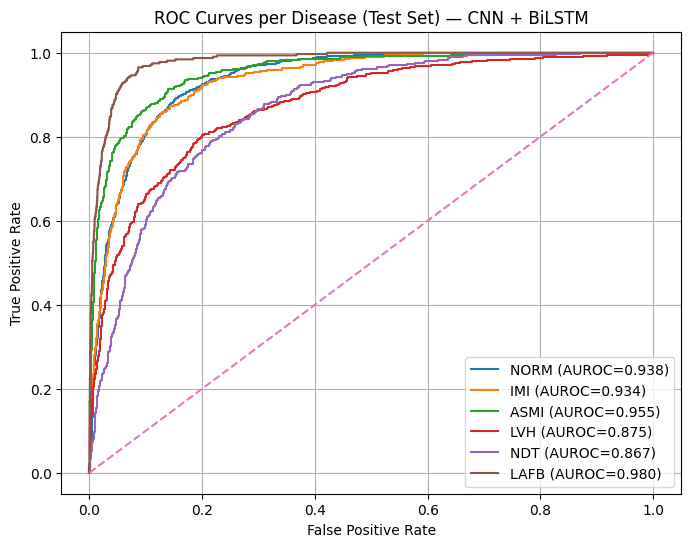

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for i, cls in enumerate(classes):
    y_true_c = te_y[:, i].astype(int)
    y_score_c = te_probs[:, i]

    if len(np.unique(y_true_c)) < 2:
        print(f"{cls}: ROC undefined (only one label present).")
        continue

    fpr, tpr, _ = roc_curve(y_true_c, y_score_c)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUROC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves per Disease (Test Set) — CNN + BiLSTM")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


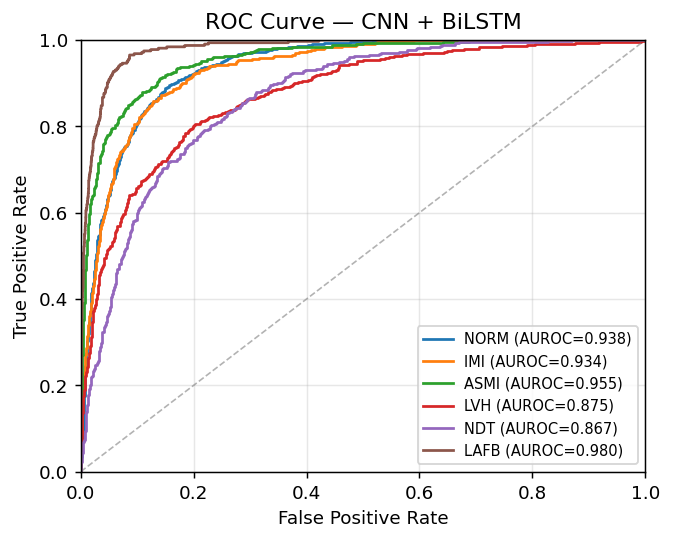

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(5.2, 4.2), dpi=132)
ax = plt.gca()

# Exact axis limits + no padding
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.margins(x=0, y=0)

for i, cls in enumerate(classes):
    y_true_c = te_y[:, i].astype(int)
    y_score_c = te_probs[:, i]

    if len(np.unique(y_true_c)) < 2:
        print(f"{cls}: ROC undefined (only one label present).")
        continue

    fpr, tpr, _ = roc_curve(y_true_c, y_score_c)
    roc_auc = auc(fpr, tpr)

    ax.plot(
        fpr,
        tpr,
        lw=1.5,
        label=f"{cls} (AUROC={roc_auc:.3f})"
    )

# Light diagonal reference line (so it doesn't dominate)
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    lw=0.9,
    alpha=0.6
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — CNN + BiLSTM")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# If saving for paper:
# plt.savefig("CNN_BiLSTM_ROC.png", dpi=132, bbox_inches="tight")


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# you should already have va_logits, va_y from training loop; if not, run:
# _, va_logits, va_y = run_epoch(val_loader, train=False)
va_probs = sigmoid_np(va_logits)

grid = np.linspace(0.05, 0.95, 19)
best_thr = np.zeros(len(classes))

for i in range(len(classes)):
    best_f1, best_t = -1, 0.5
    for t in grid:
        pred = (va_probs[:, i] >= t).astype(int)
        f1 = f1_score(va_y[:, i].astype(int), pred, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    best_thr[i] = best_t

print("Best thresholds (from VAL):")
for cls, t in zip(classes, best_thr):
    print(f"{cls:6s}: {t:.2f}")

# Apply tuned thresholds on TEST
y_pred_tuned = np.zeros_like(y_true)
for i in range(len(classes)):
    y_pred_tuned[:, i] = (te_probs[:, i] >= best_thr[i]).astype(int)

macro_f1_tuned = f1_score(y_true, y_pred_tuned, average="macro", zero_division=0)
print("TEST Macro F1 with tuned thresholds:", macro_f1_tuned)


Best thresholds (from VAL):
NORM  : 0.60
IMI   : 0.15
ASMI  : 0.30
LVH   : 0.25
NDT   : 0.20
LAFB  : 0.20
TEST Macro F1 with tuned thresholds: 0.6187897275350903
